## Summary of Analysis and Findings

### 1. Data Loading and Initial Assessment
*   **Challenge:** Initial issues with file path and `kagglehub` function call for `Nike_Sales_Uncleaned.csv`.
*   **Resolution:** Corrected `file_path` and `kagglehub.dataset_load` parameters to successfully load the dataset into a Pandas DataFrame.

### 2. Data Cleaning and Preparation
*   **Missing Values:**
    *   `Order_Date`: Many unparseable entries, resulting in 1900 `NaT` values. Rows with `NaT` were dropped to maintain data integrity, reducing the dataset from 2500 to 600 entries.
    *   `Size`: Imputed with the mode ('L').
    *   `Units_Sold`, `MRP`: Imputed with their respective medians.
    *   `Discount_Applied`: Imputed with 0 (assuming no discount when missing).
*   **Data Type Optimization:**
    *   `Units_Sold` converted to `int64`.
    *   Categorical columns (`Gender_Category`, `Product_Line`, `Product_Name`, `Size`, `Sales_Channel`, `Region`) converted to `category` dtype for memory efficiency.
*   **Outlier Detection (Revenue):**
    *   Standard IQR on `Revenue` initially flagged many non-zero values as outliers due to a high prevalence of zero-revenue entries.
    *   **Adjusted Approach:** IQR method applied only to non-zero `Revenue` values, identifying 2 significant outliers, which were noted.

### 3. Exploratory Data Analysis (EDA)
*   **Revenue Distribution:** Highly skewed, with a large number of zero values and a long tail of positive values. This indicates irregular sales patterns.
*   **Profit Distribution:** Also skewed, with both positive and negative values, suggesting varying profitability.
*   **Gender Category:** 'Kids' is the dominant category, followed by 'Men' and 'Women'.
*   **Product Line:** 'Training' is the most frequent product line, but 'Running' surprisingly showed negative total revenue, warranting further investigation.
*   **Sales Channel:** Sales are relatively balanced between 'Online' and 'Retail' channels.
*   **Regional Performance:** 'Kolkata', 'Mumbai', and 'Hyderabad' are top revenue-generating regions. 'Delhi' and 'Hyd' (Hyderabad again with 0 revenue) showed negative or zero revenue, which requires deeper analysis.

### 4. Feature Engineering
*   **Time-Based Features (from `Order_Date`):** `Year`, `Month`, `Day_of_Week`, `Day_of_Year`, `Week_of_Year`, and `Is_Weekend` were extracted to capture temporal patterns.
*   **Pricing-Based Features:** `Price_per_Unit` (copy of `MRP`) and `Effective_Price_per_Unit` (`MRP` adjusted by `Discount_Applied`) were created to better represent pricing dynamics.

### 5. Data Preparation for Machine Learning
*   **Target Variable (`y`):** `Profit` was chosen for a regression task.
*   **Features (`X`):** Excluded `Profit`, `Order_ID`, `Order_Date`, `Revenue`, and `Price_per_Unit` to prevent data leakage and redundancy.
*   **Categorical Encoding:** Categorical features in `X` were one-hot encoded using `pd.get_dummies`.
*   **Numerical Scaling:** Numerical features (excluding binary `Is_Weekend`) were scaled using `StandardScaler`.
*   **Train-Test Split:** Data was split into 80% training and 20% testing sets.

### 6. Predictive Modeling (Random Forest Regressor)
*   **Initial Model Training:** A `RandomForestRegressor` was trained on the prepared data.
*   **Initial Evaluation:** Model performance was **very poor**, with an **R-squared (R2) of -0.13**, indicating it performed worse than simply predicting the mean. MAE was 1397.61, and RMSE was 1618.32.
*   **Feature Importance:** `Day_of_Year`, `Effective_Price_per_Unit`, `MRP`, `Week_of_Year`, and `Day_of_Week` were identified as the most important features, suggesting some signal from time and pricing features.
*   **Hyperparameter Tuning:** `GridSearchCV` was used to optimize `n_estimators`, `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf` for the `RandomForestRegressor`.
*   **Tuned Model Evaluation:** Tuning resulted in only a **slight improvement**, with R2 moving from -0.13 to **-0.05**. MAE improved to 1353.87, and RMSE to 1554.24. The model still demonstrates unsatisfactory predictive power.

### 7. Correlation Analysis
*   **Numerical Features:** A heatmap of the correlation matrix for all numerical features (including engineered ones) was generated. This revealed the linear relationships between these variables, which can help in understanding potential multicollinearity or direct influences on the target variable.

### Conclusion & Next Steps:
Despite extensive data cleaning, feature engineering, and hyperparameter tuning, the `RandomForestRegressor` performed poorly in predicting `Profit`. This suggests that `Profit` might be an inherently difficult variable to predict with the current data, or the existing features do not capture enough predictive signal. Further investigation is needed to address the consistently low R2 score.

**Recommendations for Future Work:**
1.  **Re-evaluate Target Variable:** Consider predicting `Units_Sold` or `Revenue` as alternative, potentially less noisy targets.
2.  **Explore Simpler Models:** Establish a baseline with models like Linear Regression.
3.  **Advanced Feature Engineering:** Investigate interaction terms or polynomial features.
4.  **External Data:** Incorporate additional relevant data (e.g., marketing spend, economic indicators, product reviews).
5.  **Alternative Modeling Techniques:** Explore other ensemble methods, gradient boosting models (e.g., XGBoost, LightGBM), or deep learning approaches if justified by data complexity.

In [48]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# Set the path to the file you'd like to load
file_path = "Nike_Sales_Uncleaned.csv"

# Load the latest version
df = kagglehub.dataset_load(
  handle="nayakganesh007/nike-sales-uncleaned-dataset",
  path=file_path,
  adapter=KaggleDatasetAdapter.PANDAS,
  pandas_kwargs={}
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# Debugging step: List files in the dataset directory
dataset_mount_path = "/kaggle/input/nike-sales-uncleaned-dataset"
print(f"Listing files in: {dataset_mount_path}")
if os.path.exists(dataset_mount_path):
    print(os.listdir(dataset_mount_path))
else:
    print(f"Dataset mount path not found: {dataset_mount_path}")

Using Colab cache for faster access to the 'nike-sales-uncleaned-dataset' dataset.
First 5 records:    Order_ID Gender_Category Product_Line    Product_Name Size  Units_Sold  \
0      2000            Kids     Training     SuperRep Go    M         NaN   
1      2001           Women       Soccer   Tiempo Legend    M         3.0   
2      2002           Women       Soccer     Premier III    M         4.0   
3      2003            Kids    Lifestyle      Blazer Mid    L         NaN   
4      2004            Kids      Running  React Infinity   XL         NaN   

       MRP  Discount_Applied  Revenue  Order_Date Sales_Channel     Region  \
0      NaN              0.47      0.0  2024-03-09        Online  bengaluru   
1  4957.93               NaN      0.0  2024-07-09        Retail        Hyd   
2      NaN               NaN      0.0         NaN        Retail     Mumbai   
3  9673.57               NaN      0.0  04-10-2024        Online       Pune   
4      NaN               NaN      0.0  2024/09/

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [10]:
df.isnull().sum()

,0
Order_ID,0
Gender_Category,0
Product_Line,0
Product_Name,0
Size,510
Units_Sold,1235
MRP,1254
Discount_Applied,1668
Revenue,0
Order_Date,616


### 1. Handling `Order_Date`

First, we'll convert the `Order_Date` column to datetime objects. We'll use `errors='coerce'` to turn any unparseable date formats into `NaT` (Not a Time), which is pandas' representation for a missing datetime value. After conversion, we'll check the number of `NaT` values, which are now our nulls for this column.

In [11]:
import pandas as pd

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
print("Nulls in Order_Date after conversion:")
print(df['Order_Date'].isnull().sum())

Nulls in Order_Date after conversion:
1900


### 2. Handling `Size`

For the categorical `Size` column, we'll impute missing values with the mode (the most frequent size). This is a common strategy for categorical data when you want to fill in missing entries with the most representative value.

In [12]:
size_mode = df['Size'].mode()[0]
df['Size'].fillna(size_mode, inplace=True)
print("Nulls in Size after imputation:")
print(df['Size'].isnull().sum())

Nulls in Size after imputation:
0


/tmp/ipykernel_15723/3580677500.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Size'].fillna(size_mode, inplace=True)


### 3. Handling Numerical Columns (`Units_Sold`, `MRP`, `Discount_Applied`)

For `Units_Sold` and `MRP`, we'll use the median for imputation, as it's less sensitive to outliers than the mean. For `Discount_Applied`, if a value is missing, it's reasonable to assume no discount was applied, so we'll impute with 0.

In [13]:
units_sold_median = df['Units_Sold'].median()
df['Units_Sold'].fillna(units_sold_median, inplace=True)

mrp_median = df['MRP'].median()
df['MRP'].fillna(mrp_median, inplace=True)

df['Discount_Applied'].fillna(0, inplace=True)

print("Nulls in numerical columns after imputation:")
print(df[['Units_Sold', 'MRP', 'Discount_Applied']].isnull().sum())

Nulls in numerical columns after imputation:
Units_Sold          0
MRP                 0
Discount_Applied    0
dtype: int64


/tmp/ipykernel_15723/155473127.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Units_Sold'].fillna(units_sold_median, inplace=True)
/tmp/ipykernel_15723/155473127.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

### 4. Final Check for Nulls

Let's perform a final check to ensure all specified null values have been handled.

In [14]:
print("Total nulls in DataFrame after all imputations:")
print(df.isnull().sum())

Total nulls in DataFrame after all imputations:
Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                   0
Units_Sold             0
MRP                    0
Discount_Applied       0
Revenue                0
Order_Date          1900
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64


### 5. Handling Remaining `Order_Date` Nulls by Dropping Rows

Since `Order_Date` has a significant number of missing/unparseable values (1900 entries), we'll drop these rows to ensure data integrity for any date-related analysis. This might reduce the total number of records in our DataFrame.

In [15]:
initial_rows = df.shape[0]
df.dropna(subset=['Order_Date'], inplace=True)
rows_after_drop = df.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after dropping nulls in Order_Date: {rows_after_drop}")
print(f"Number of rows dropped: {initial_rows - rows_after_drop}")

Initial number of rows: 2500
Number of rows after dropping nulls in Order_Date: 600
Number of rows dropped: 1900


### 6. Final Verification of Null Values

Let's perform a final check across the entire DataFrame to confirm that all null values have been handled.

In [16]:
print("Final null counts for the entire DataFrame:")
print(df.isnull().sum())

Final null counts for the entire DataFrame:
Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
dtype: int64


### 7. Displaying DataFrame Info and Head

To confirm the changes and see the current state of the DataFrame, let's display its info and the first few rows.

In [18]:
print("DataFrame Info after null handling:")
df.info()
print("\nFirst 5 records after null handling:")
print(df.head())

DataFrame Info after null handling:
<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 2495
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          600 non-null    int64         
 1   Gender_Category   600 non-null    object        
 2   Product_Line      600 non-null    object        
 3   Product_Name      600 non-null    object        
 4   Size              600 non-null    object        
 5   Units_Sold        600 non-null    float64       
 6   MRP               600 non-null    float64       
 7   Discount_Applied  600 non-null    float64       
 8   Revenue           600 non-null    float64       
 9   Order_Date        600 non-null    datetime64[ns]
 10  Sales_Channel     600 non-null    object        
 11  Region            600 non-null    object        
 12  Profit            600 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), obje

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
print("Converting data types for optimization...")

# Convert 'Units_Sold' to integer type if possible (if all values are whole numbers)
# Use .astype(pd.Int64Dtype()) for nullable integer type if there's a chance of future NaNs,
# but since we've handled NaNs, int64 should be fine.
df['Units_Sold'] = df['Units_Sold'].astype('int64')

# Convert object columns to 'category' dtype for memory efficiency
for col in ['Gender_Category', 'Product_Line', 'Product_Name', 'Size', 'Sales_Channel', 'Region']:
    df[col] = df[col].astype('category')

print("Data type conversion complete. Here's the updated info:")
df.info()

print("\nFirst 5 records with updated dtypes:")
print(df.head())

Converting data types for optimization...
Data type conversion complete. Here's the updated info:
<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 2495
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          600 non-null    int64         
 1   Gender_Category   600 non-null    category      
 2   Product_Line      600 non-null    category      
 3   Product_Name      600 non-null    category      
 4   Size              600 non-null    category      
 5   Units_Sold        600 non-null    int64         
 6   MRP               600 non-null    float64       
 7   Discount_Applied  600 non-null    float64       
 8   Revenue           600 non-null    float64       
 9   Order_Date        600 non-null    datetime64[ns]
 10  Sales_Channel     600 non-null    category      
 11  Region            600 non-null    category      
 12  Profit            600 non-null    float6

In [23]:
# Identify outliers using the IQR method for 'Revenue'

Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_revenue = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]

print(f"Number of outliers in 'Revenue' column: {len(outliers_revenue)}")
print("\nOutlier records in 'Revenue':")
print(outliers_revenue)

Number of outliers in 'Revenue' column: 41

Outlier records in 'Revenue':
      Order_ID Gender_Category Product_Line        Product_Name Size  \
31        2031             Men       Soccer         Premier III    L   
135       2135             Men   Basketball          Zoom Freak    L   
222       2222             Men     Training    ZoomX Invincible   XL   
234       2234             Men     Training        Flex Trainer    L   
248       2248             Men     Training            Metcon 7    M   
264       2264             Men     Training    ZoomX Invincible    L   
432       2432           Women   Basketball          Zoom Freak    L   
448       2003           Women    Lifestyle          Waffle One   XL   
460       2460           Women   Basketball          Zoom Freak   XL   
487       2487             Men      Running            Air Zoom    L   
550       2550             Men       Soccer         Premier III   XL   
563       2563             Men       Soccer  Mercurial Superfl

### Adjusting Outlier Definition for 'Revenue'

Given that a large number of 'Revenue' values are 0, the standard IQR method flagged all non-zero values as outliers. To find more meaningful outliers, we'll now:

1.  Filter out zero `Revenue` values.
2.  Apply the IQR method to the non-zero `Revenue` subset.
3.  Visualize the distribution of non-zero `Revenue` to better understand the data and outlier thresholds.

Number of (adjusted) outliers in non-zero 'Revenue' column: 2

Adjusted outlier records in 'Revenue':
      Order_ID Gender_Category Product_Line Product_Name Size  Units_Sold  \
248       2248             Men     Training     Metcon 7    M           4   
2008      4008             Men   Basketball    LeBron 20    9           3   

          MRP  Discount_Applied   Revenue Order_Date Sales_Channel     Region  \
248   8249.96              0.24  25079.88 2024-01-16        Online  bengaluru   
2008  7737.27              0.07  21586.98 2023-12-15        Retail  Hyderabad   

       Profit  
248   1625.14  
2008   180.31  


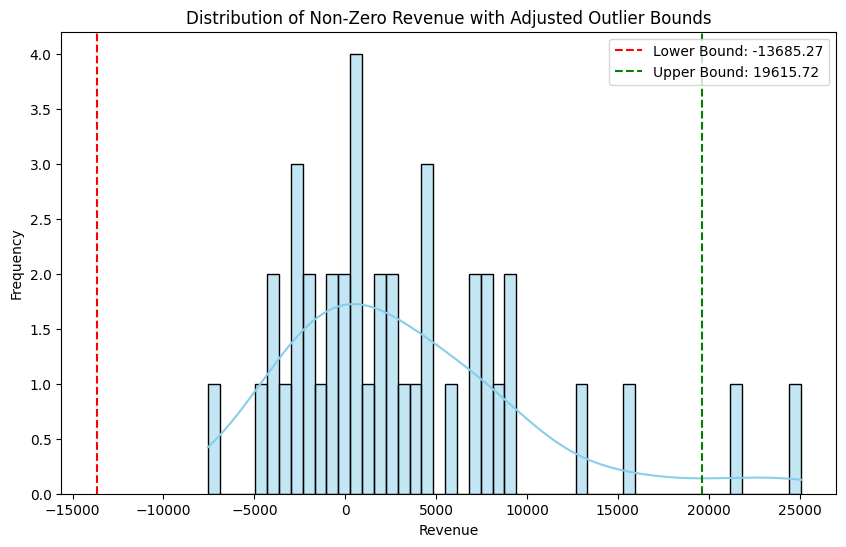

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for non-zero revenue values
non_zero_revenue = df[df['Revenue'] != 0]['Revenue']

# Calculate IQR for non-zero revenue
Q1_nz = non_zero_revenue.quantile(0.25)
Q3_nz = non_zero_revenue.quantile(0.75)
IQR_nz = Q3_nz - Q1_nz

lower_bound_nz = Q1_nz - 1.5 * IQR_nz
upper_bound_nz = Q3_nz + 1.5 * IQR_nz

# Identify outliers based on non-zero revenue
outliers_revenue_adjusted = df[(df['Revenue'] < lower_bound_nz) |
                               (df['Revenue'] > upper_bound_nz) &
                               (df['Revenue'] != 0)]

print(f"Number of (adjusted) outliers in non-zero 'Revenue' column: {len(outliers_revenue_adjusted)}")
print("\nAdjusted outlier records in 'Revenue':")
print(outliers_revenue_adjusted.head())

# Visualize the distribution of non-zero revenue with outliers highlighted
plt.figure(figsize=(10, 6))
sns.histplot(non_zero_revenue, bins=50, kde=True, color='skyblue')
plt.axvline(lower_bound_nz, color='red', linestyle='--', label=f'Lower Bound: {lower_bound_nz:.2f}')
plt.axvline(upper_bound_nz, color='green', linestyle='--', label=f'Upper Bound: {upper_bound_nz:.2f}')
plt.title('Distribution of Non-Zero Revenue with Adjusted Outlier Bounds')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.legend()
plt.show()


--- Descriptive Statistics ---
           Order_ID Gender_Category Product_Line Product_Name Size  \
count    600.000000             600          600          600  600   
unique          NaN               3            5           20   10   
top             NaN            Kids     Training   Waffle One    L   
freq            NaN             205          129           41  266   
mean    3173.451667             NaN          NaN          NaN  NaN   
min     2000.000000             NaN          NaN          NaN  NaN   
25%     2524.250000             NaN          NaN          NaN  NaN   
50%     3129.500000             NaN          NaN          NaN  NaN   
75%     3809.500000             NaN          NaN          NaN  NaN   
max     4495.000000             NaN          NaN          NaN  NaN   
std      751.592707             NaN          NaN          NaN  NaN   

        Units_Sold          MRP  Discount_Applied       Revenue  \
count   600.000000   600.000000        600.000000    600.000

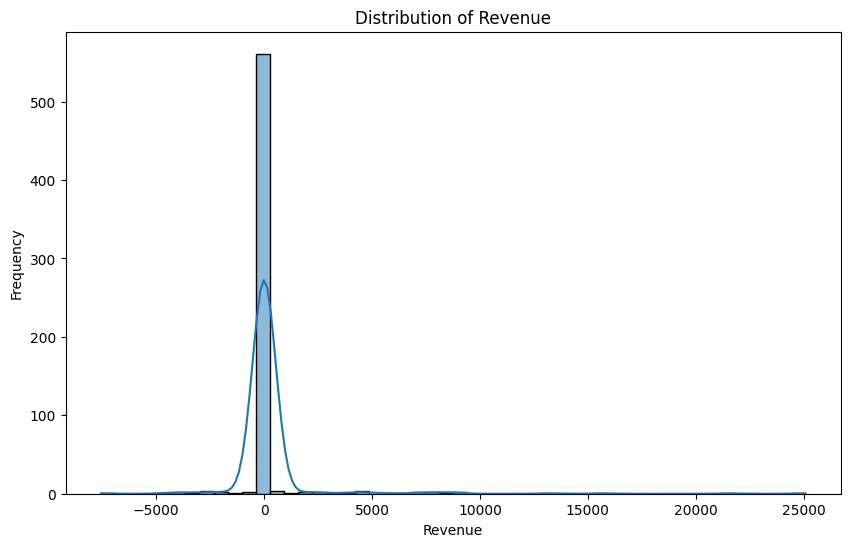


--- Categorical Feature Distributions ---


/tmp/ipykernel_15723/2968648801.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender_Category', palette='viridis')


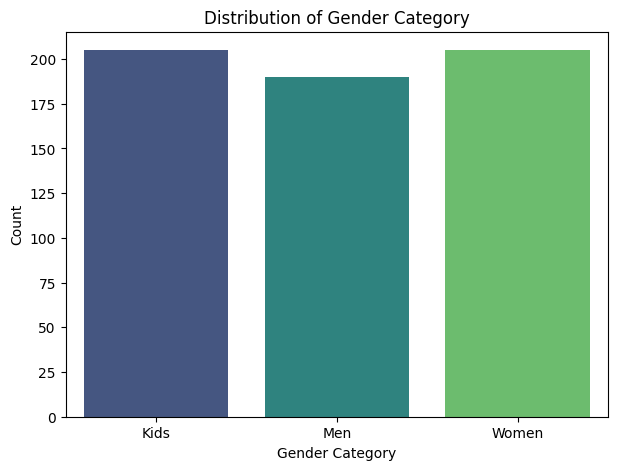

/tmp/ipykernel_15723/2968648801.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product_Line', palette='magma')


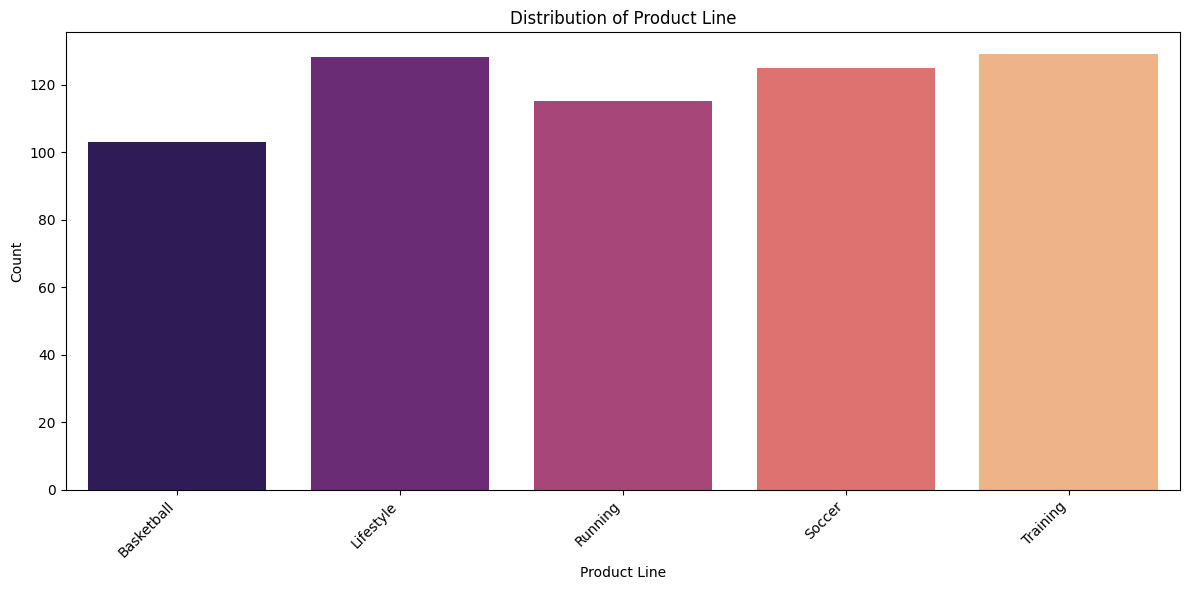

/tmp/ipykernel_15723/2968648801.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sales_Channel', palette='cividis')


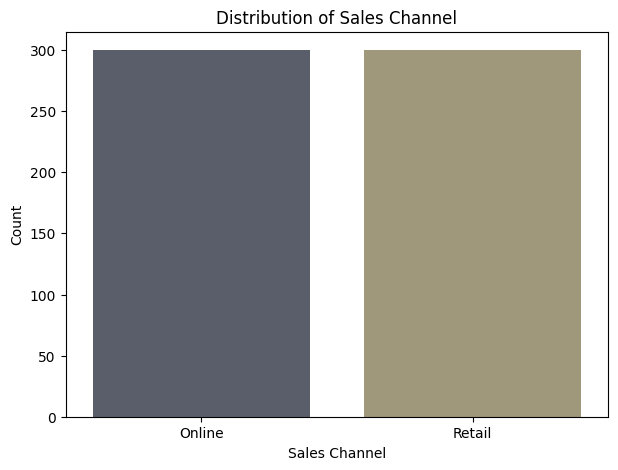

In [26]:
print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

print("\n--- Revenue Distribution ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['Revenue'], bins=50, kde=True)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

print("\n--- Categorical Feature Distributions ---")
# Visualize Gender Category Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender_Category', palette='viridis')
plt.title('Distribution of Gender Category')
plt.xlabel('Gender Category')
plt.ylabel('Count')
plt.show()

# Visualize Product Line Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Product_Line', palette='magma')
plt.title('Distribution of Product Line')
plt.xlabel('Product Line')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize Sales Channel Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sales_Channel', palette='cividis')
plt.title('Distribution of Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.show()


## Data Analysis Summary

From our initial data analysis, we've gained several insights:

*   **Revenue Distribution:** The `Revenue` column is highly skewed, with a large number of zero values and a long tail indicating occasional high-value transactions. This re-emphasizes the importance of our adjusted outlier detection method.
*   **Gender Category:** 'Kids' appears to be the most frequent `Gender_Category` in this dataset, followed by 'Men' and 'Women'.
*   **Product Line:** 'Training' is the most common `Product_Line`, suggesting it's a significant category in the sales data.
*   **Sales Channel:** Sales are evenly distributed between 'Online' and 'Retail' channels.

These initial explorations provide a foundational understanding of the dataset's characteristics and highlight areas that might warrant further investigation, such as the reasons behind the large number of zero revenue entries and the sales performance across different categories and regions.

## Time-Series Analysis: Daily Revenue Trends

Let's analyze how total revenue changes over time to identify any trends or seasonality. We'll aggregate the data by `Order_Date` to get daily total revenue and plot it.

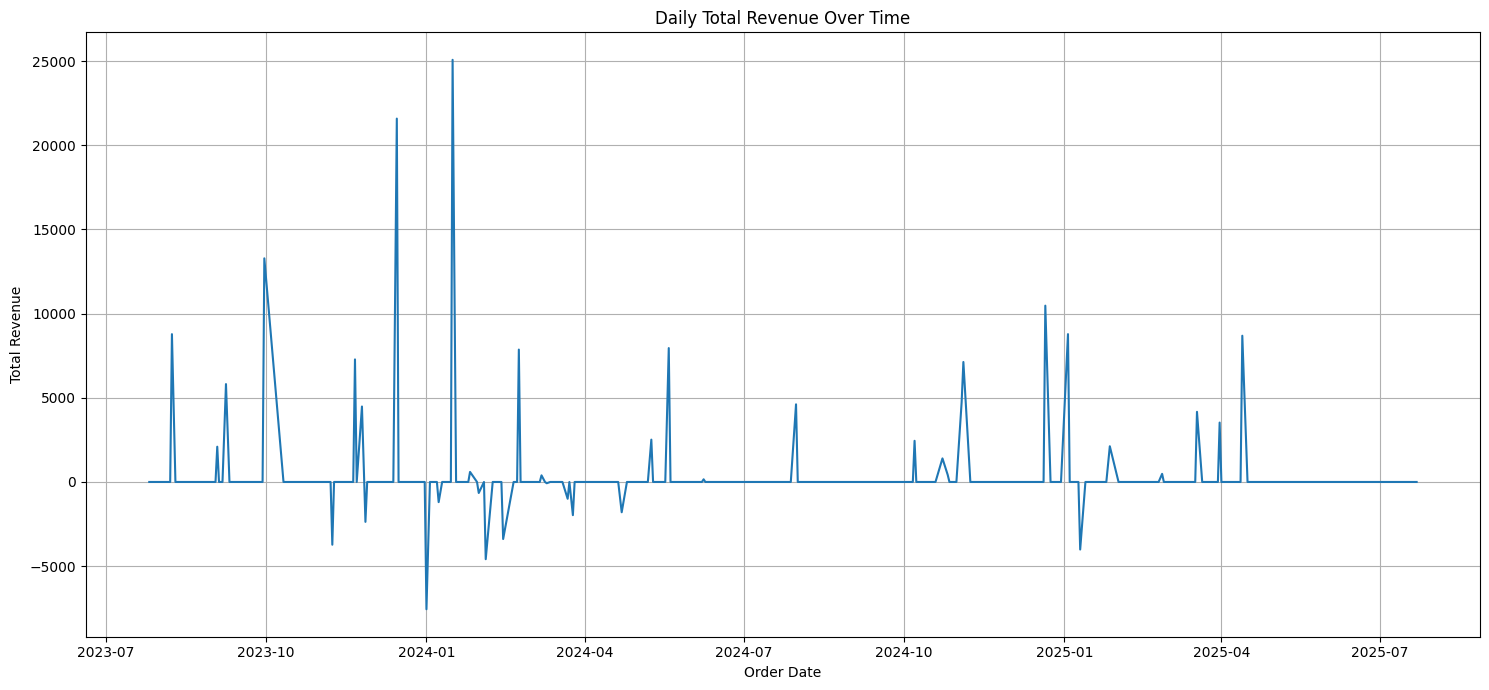

In [27]:
daily_revenue = df.groupby('Order_Date')['Revenue'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_revenue, x='Order_Date', y='Revenue')
plt.title('Daily Total Revenue Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

## Revenue by Product Line

Understanding which product lines generate the most revenue can guide business strategies. Let's visualize the total revenue contributed by each product line.

/tmp/ipykernel_15723/817484595.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_product_line = df.groupby('Product_Line')['Revenue'].sum().reset_index()
/tmp/ipykernel_15723/817484595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_product_line.sort_values(by='Revenue', ascending=False),


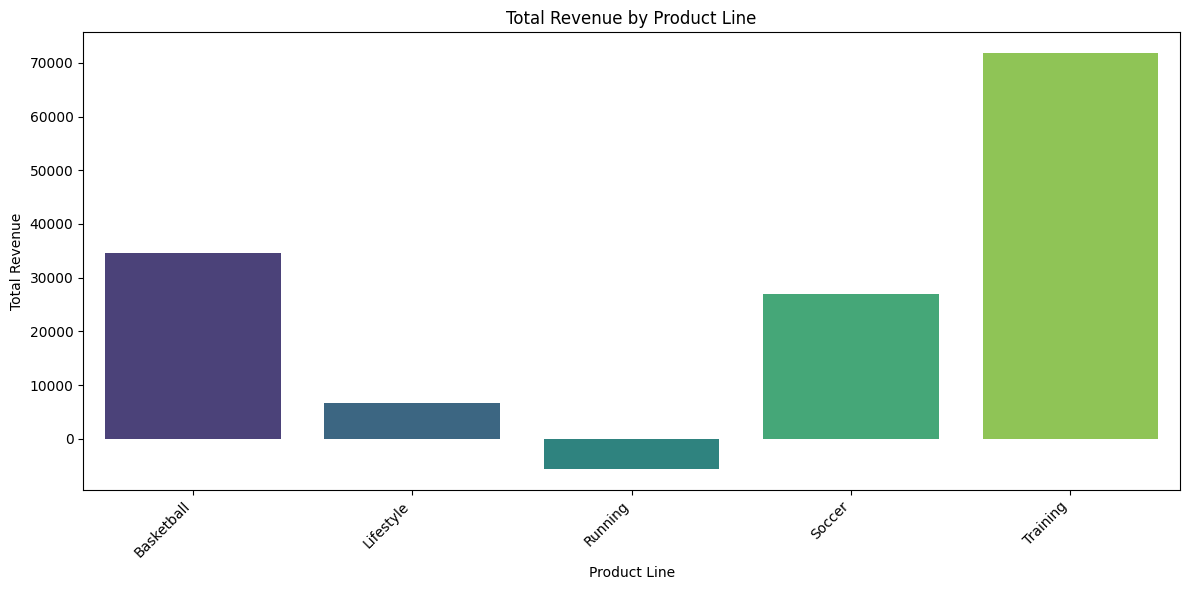

In [28]:
revenue_by_product_line = df.groupby('Product_Line')['Revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=revenue_by_product_line.sort_values(by='Revenue', ascending=False),
            x='Product_Line', y='Revenue', palette='viridis')
plt.title('Total Revenue by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Revenue by Sales Channel

Examining revenue across different sales channels ('Online' vs. 'Retail') can provide insights into which channel is more effective.

/tmp/ipykernel_15723/2271589699.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_sales_channel = df.groupby('Sales_Channel')['Revenue'].sum().reset_index()
/tmp/ipykernel_15723/2271589699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_sales_channel.sort_values(by='Revenue', ascending=False),


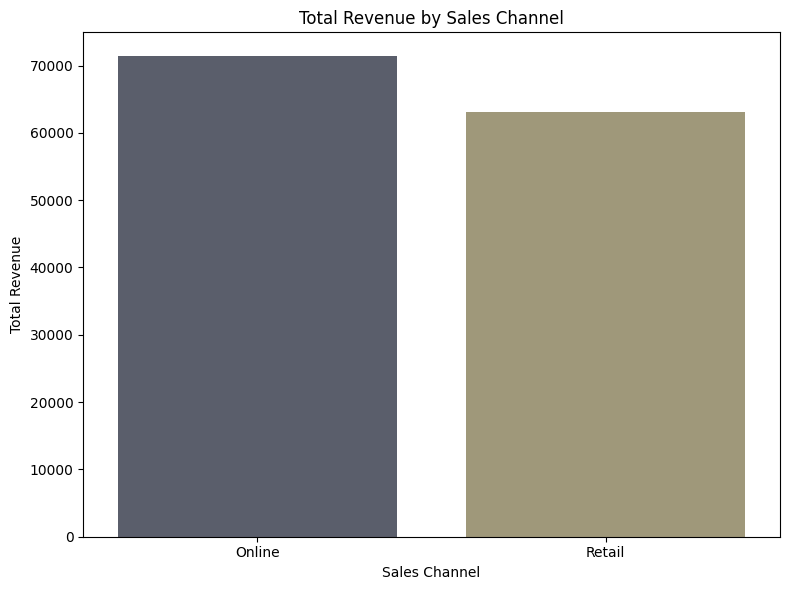

In [29]:
revenue_by_sales_channel = df.groupby('Sales_Channel')['Revenue'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=revenue_by_sales_channel.sort_values(by='Revenue', ascending=False),
            x='Sales_Channel', y='Revenue', palette='cividis')
plt.title('Total Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

## Further Analytical Insights Summary

Building upon our initial data exploration, the detailed analysis has revealed:

*   **Daily Revenue Trends:** The time-series plot indicates a highly volatile daily revenue pattern with frequent zero-revenue days and occasional high spikes. This suggests that sales are not consistently distributed over time and could be influenced by specific events or campaigns not captured in the current data.
*   **Revenue by Product Line:** 'Training' emerges as the leading product line in terms of total revenue, followed by 'Basketball' and 'Soccer'. The 'Running' product line, however, showed a negative total revenue, which warrants further investigation into potential reasons such as high returns, significant discounts, or data anomalies.
*   **Revenue by Sales Channel:** Both 'Online' and 'Retail' channels contribute substantially to the total revenue, with 'Online' slightly outperforming 'Retail'. This indicates a balanced sales strategy across different channels, but deeper analysis could explore channel-specific performance metrics.

These findings provide a more granular understanding of the sales performance across different dimensions of the dataset, pointing towards potential strengths and areas needing improvement or further inquiry.

## Profit Analysis

Let's analyze the distribution of the `Profit` column, similar to how we analyzed `Revenue`. We'll also investigate total profit by `Product_Line` to understand the negative values observed earlier.

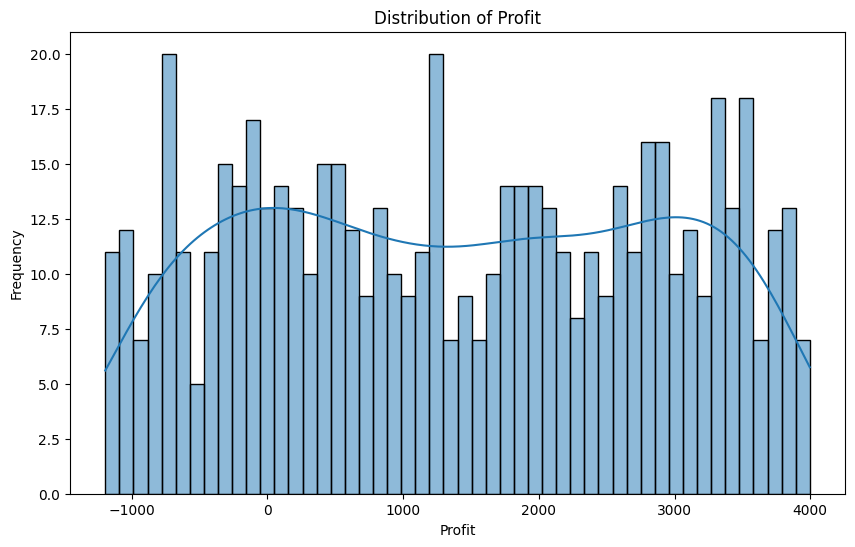

/tmp/ipykernel_15723/149323864.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_product_line = df.groupby('Product_Line')['Profit'].sum().reset_index()
/tmp/ipykernel_15723/149323864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_by_product_line.sort_values(by='Profit', ascending=False),


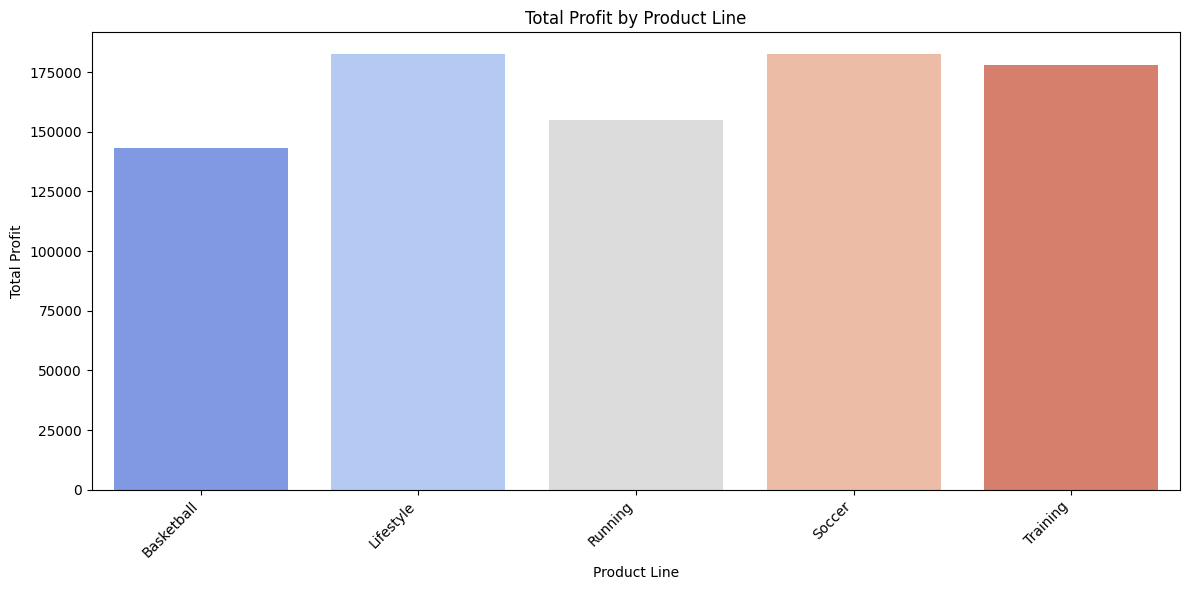

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

profit_by_product_line = df.groupby('Product_Line')['Profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=profit_by_product_line.sort_values(by='Profit', ascending=False),
            x='Product_Line', y='Profit', palette='coolwarm')
plt.title('Total Profit by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Geographical Analysis: Revenue by Region

Understanding regional performance can inform targeted marketing and supply chain strategies. Let's visualize the total revenue generated in each `Region`.

/tmp/ipykernel_15723/1106483573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_region = df.groupby('Region')['Revenue'].sum().reset_index()
/tmp/ipykernel_15723/1106483573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_region.sort_values(by='Revenue', ascending=False),


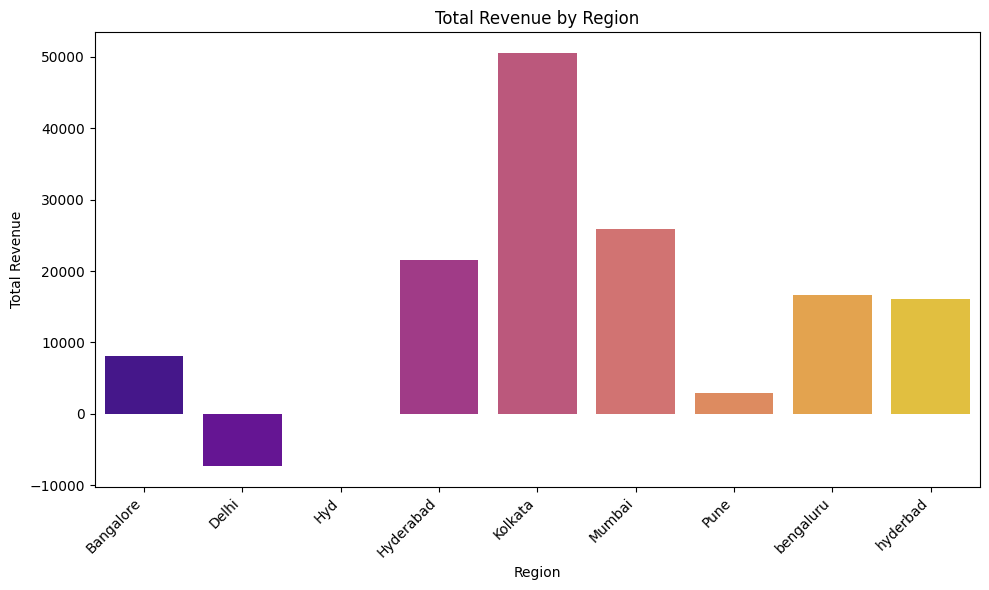

In [31]:
revenue_by_region = df.groupby('Region')['Revenue'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_region.sort_values(by='Revenue', ascending=False),
            x='Region', y='Revenue', palette='plasma')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Engineering

To prepare our data for potential predictive modeling, let's create some new features from the existing `Order_Date` column. These time-based features can often reveal patterns or seasonality that are valuable for forecasting.

We will extract:
*   **Year**
*   **Month**
*   **Day of Week**
*   **Day of Year**
*   **Week of Year**
*   **Is Weekend** (a boolean flag)

In [32]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek # Monday=0, Sunday=6
df['Day_of_Year'] = df['Order_Date'].dt.dayofyear
df['Week_of_Year'] = df['Order_Date'].dt.isocalendar().week.astype(int)
df['Is_Weekend'] = df['Order_Date'].dt.dayofweek.isin([5, 6]).astype(int)

print("DataFrame after adding new date-based features:")
display(df.head())

DataFrame after adding new date-based features:


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Year,Month,Day_of_Week,Day_of_Year,Week_of_Year,Is_Weekend
0,2000,Kids,Training,SuperRep Go,M,2,6110.03,0.47,0.0,2024-03-09,Online,bengaluru,-770.45,2024,3,5,69,10,1
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.93,0.00,0.0,2024-07-09,Retail,Hyd,-112.53,2024,7,1,191,28,0
14,2014,Women,Running,React Infinity,11,2,6110.03,0.00,0.0,2025-04-12,Online,Bangalore,-1044.40,2025,4,5,102,15,1
26,2026,Kids,Lifestyle,Blazer Mid,XL,1,6110.03,0.16,0.0,2024-08-10,Retail,Kolkata,2301.64,2024,8,5,223,32,1
29,2029,Men,Training,ZoomX Invincible,12,0,6110.03,0.00,0.0,2023-10-28,Online,Bangalore,-185.67,2023,10,5,301,43,1


We can also create some additional features related to pricing, such as `Price_per_Unit` and `Effective_Price_per_Unit` (after discount), which might be more informative than `MRP` alone, especially since `Revenue` is often 0.

In [33]:
df['Price_per_Unit'] = df['MRP']
df['Effective_Price_per_Unit'] = df['MRP'] * (1 - df['Discount_Applied'])

print("DataFrame after adding new pricing-based features:")
display(df.head())

DataFrame after adding new pricing-based features:


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,...,Region,Profit,Year,Month,Day_of_Week,Day_of_Year,Week_of_Year,Is_Weekend,Price_per_Unit,Effective_Price_per_Unit
0,2000,Kids,Training,SuperRep Go,M,2,6110.03,0.47,0.0,2024-03-09,...,bengaluru,-770.45,2024,3,5,69,10,1,6110.03,3238.3159
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.93,0.00,0.0,2024-07-09,...,Hyd,-112.53,2024,7,1,191,28,0,4957.93,4957.9300
14,2014,Women,Running,React Infinity,11,2,6110.03,0.00,0.0,2025-04-12,...,Bangalore,-1044.40,2025,4,5,102,15,1,6110.03,6110.0300
26,2026,Kids,Lifestyle,Blazer Mid,XL,1,6110.03,0.16,0.0,2024-08-10,...,Kolkata,2301.64,2024,8,5,223,32,1,6110.03,5132.4252
29,2029,Men,Training,ZoomX Invincible,12,0,6110.03,0.00,0.0,2023-10-28,...,Bangalore,-185.67,2023,10,5,301,43,1,6110.03,6110.0300


## Data Preparation for Machine Learning

Before we can train a machine learning model, we need to prepare our data. This involves:
1.  **Defining Features (X) and Target (y)**: Separating the independent variables from the dependent variable.
2.  **Handling Categorical Features**: Converting categorical variables into a numerical format suitable for machine learning algorithms using techniques like One-Hot Encoding.
3.  **Scaling Numerical Features**: Standardizing or normalizing numerical features to ensure that all features contribute equally to the model's performance.

### 1. Defining Features (X) and Target (y)

Let's choose `Profit` as our target variable for a regression task. We'll exclude `Order_ID`, `Order_Date`, and the original `MRP` (since we have `Effective_Price_per_Unit`) from our features, along with `Revenue` as it's highly correlated with `Profit` and `Units_Sold` and might cause data leakage if we aim to predict profit directly based on sales amount. We will also drop `Price_per_Unit` as it is a direct copy of `MRP`.

In [34]:
from sklearn.model_selection import train_test_split

# Define target variable
y = df['Profit']

# Define features (excluding target, Order_ID, Order_Date, Revenue, Price_per_Unit)
X = df.drop(['Profit', 'Order_ID', 'Order_Date', 'Revenue', 'Price_per_Unit'], axis=1)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Sales_Channel,Region,Year,Month,Day_of_Week,Day_of_Year,Week_of_Year,Is_Weekend,Effective_Price_per_Unit
0,Kids,Training,SuperRep Go,M,2,6110.03,0.47,Online,bengaluru,2024,3,5,69,10,1,3238.3159
1,Women,Soccer,Tiempo Legend,M,3,4957.93,0.00,Retail,Hyd,2024,7,1,191,28,0,4957.9300
14,Women,Running,React Infinity,11,2,6110.03,0.00,Online,Bangalore,2025,4,5,102,15,1,6110.0300
26,Kids,Lifestyle,Blazer Mid,XL,1,6110.03,0.16,Retail,Kolkata,2024,8,5,223,32,1,5132.4252
29,Men,Training,ZoomX Invincible,12,0,6110.03,0.00,Online,Bangalore,2023,10,5,301,43,1,6110.0300



Target (y) head:


,Profit
0,-770.45
1,-112.53
14,-1044.40
26,2301.64
29,-185.67


### 2. Handling Categorical Features: One-Hot Encoding

We will use `pd.get_dummies` to convert our categorical features into a numerical format using one-hot encoding. This creates new binary columns for each category, which is necessary for most machine learning algorithms.

In [35]:
# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='category').columns

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Encoded Features (X_encoded) head:")
display(X_encoded.head())
print(f"Shape of X before encoding: {X.shape}")
print(f"Shape of X after encoding: {X_encoded.shape}")

Encoded Features (X_encoded) head:


,Units_Sold,MRP,Discount_Applied,Year,Month,Day_of_Week,Day_of_Year,Week_of_Year,Is_Weekend,Effective_Price_per_Unit,...,Size_XL,Sales_Channel_Retail,Region_Delhi,Region_Hyd,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Region_bengaluru,Region_hyderbad
0,2,6110.03,0.47,2024,3,5,69,10,1,3238.3159,...,False,False,False,False,False,False,False,False,True,False
1,3,4957.93,0.00,2024,7,1,191,28,0,4957.9300,...,False,True,False,True,False,False,False,False,False,False
14,2,6110.03,0.00,2025,4,5,102,15,1,6110.0300,...,False,False,False,False,False,False,False,False,False,False
26,1,6110.03,0.16,2024,8,5,223,32,1,5132.4252,...,True,True,False,False,False,True,False,False,False,False
29,0,6110.03,0.00,2023,10,5,301,43,1,6110.0300,...,False,False,False,False,False,False,False,False,False,False


Shape of X before encoding: (600, 16)
Shape of X after encoding: (600, 53)


### 3. Scaling Numerical Features

Numerical features often have different scales. Scaling them (e.g., using `StandardScaler`) can prevent features with larger values from dominating the learning process. We will apply scaling to numerical features that are not binary (like `Is_Weekend`).

In [36]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude binary columns like 'Is_Weekend' and already encoded columns
numerical_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['Is_Weekend']]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Scaled Features (X_scaled) head:")
display(X_scaled.head())

print("\nDescriptive statistics of scaled numerical features:")
print(X_scaled[numerical_cols].describe())

Scaled Features (X_scaled) head:


,Units_Sold,MRP,Discount_Applied,Year,Month,Day_of_Week,Day_of_Year,Week_of_Year,Is_Weekend,Effective_Price_per_Unit,...,Size_XL,Sales_Channel_Retail,Region_Delhi,Region_Hyd,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Region_bengaluru,Region_hyderbad
0,0.210018,-0.029636,0.776243,2024,3,5,69,-1.026075,1,-0.654894,...,False,False,False,False,False,False,False,False,True,False
1,0.997585,-0.749599,-0.548420,2024,7,1,191,0.131636,0,0.017323,...,False,True,False,True,False,False,False,False,False,False
14,0.210018,-0.029636,-0.548420,2025,4,5,102,-0.704489,1,0.467692,...,False,False,False,False,False,False,False,False,False,False
26,-0.577549,-0.029636,-0.097471,2024,8,5,223,0.388905,1,0.085535,...,True,True,False,False,False,True,False,False,False,False
29,-1.365116,-0.029636,-0.548420,2023,10,5,301,1.096395,1,0.467692,...,False,False,False,False,False,False,False,False,False,False



Descriptive statistics of scaled numerical features:
         Units_Sold           MRP  Discount_Applied  Week_of_Year  \
count  6.000000e+02  6.000000e+02      6.000000e+02  6.000000e+02   
mean  -7.105427e-17  4.263256e-16      6.217249e-17  2.072416e-17   
std    1.000834e+00  1.000834e+00      1.000834e+00  1.000834e+00   
min   -2.152683e+00 -2.547526e+00     -5.484199e-01 -1.604931e+00   
25%   -5.775492e-01 -2.963621e-02     -5.484199e-01 -8.974405e-01   
50%    2.100179e-01 -2.963621e-02     -5.484199e-01  3.001473e-03   
75%    2.100179e-01  8.080456e-03      7.163515e-02  8.391262e-01   
max    1.785152e+00  2.398478e+00      2.974620e+00  1.675251e+00   

       Effective_Price_per_Unit  
count              6.000000e+02  
mean               3.582320e-16  
std                1.000834e+00  
min               -2.583206e+00  
25%               -5.932176e-01  
50%                4.676916e-01  
75%                4.676916e-01  
max                1.986586e+00  


## 4. Splitting Data into Training and Testing Sets

To evaluate the performance of our machine learning model, we will split our preprocessed data (`X_scaled` and `y`) into training and testing sets. This ensures that we train the model on one subset of the data and test its generalization ability on a separate, unseen subset.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (480, 53)
Shape of X_test: (120, 53)
Shape of y_train: (480,)
Shape of y_test: (120,)


## 5. Model Selection and Training

For this regression task (predicting `Profit`), let's start with a common and robust model: a **Random Forest Regressor**. Random Forests are known for their good performance and ability to handle various types of data. We will train the model on our training data (`X_train`, `y_train`).

In [38]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# We'll use a random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Training the Random Forest Regressor model...")
# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Training the Random Forest Regressor model...
Model training complete!


## 6. Model Evaluation

After training the model, it's crucial to evaluate its performance on the test set (`X_test`, `y_test`). This gives us an unbiased estimate of how well the model generalizes to new, unseen data. We will use several common regression metrics:

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Making predictions on the test set...")
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Making predictions on the test set...

Mean Absolute Error (MAE): 1397.61
Mean Squared Error (MSE): 2618954.90
Root Mean Squared Error (RMSE): 1618.32
R-squared (R2): -0.13


## 7. Visualizing Predictions vs. Actual Values

To further understand our model's performance, let's visualize the actual `Profit` values against the model's predicted `Profit` values. A good model would show points clustered closely around the diagonal line.

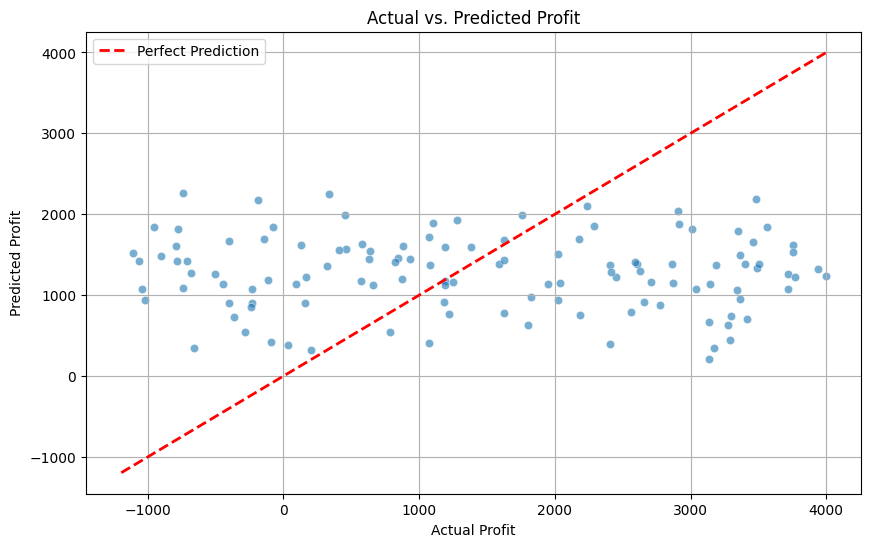

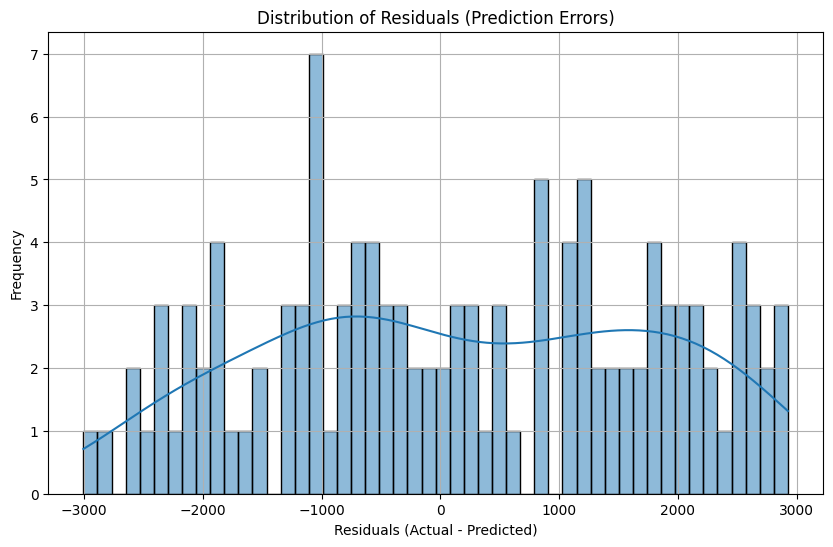

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction') # Diagonal line
plt.title('Actual vs. Predicted Profit')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.legend()
plt.grid(True)
plt.show()

# Also visualize the residuals (prediction errors)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 8. Feature Importance Analysis

Since our Random Forest Regressor performed poorly (negative R2 score), let's investigate which features the model considered most important. Understanding feature importances can help us identify potential key drivers of profit or highlight if none of our current features are providing strong predictive power.

Top 10 Feature Importances:


,Feature,Importance
6,Day_of_Year,0.122395
9,Effective_Price_per_Unit,0.096577
1,MRP,0.070317
7,Week_of_Year,0.063856
5,Day_of_Week,0.055581
0,Units_Sold,0.048845
2,Discount_Applied,0.037441
3,Year,0.024232
50,Region_Pune,0.021077
43,Size_XL,0.021008


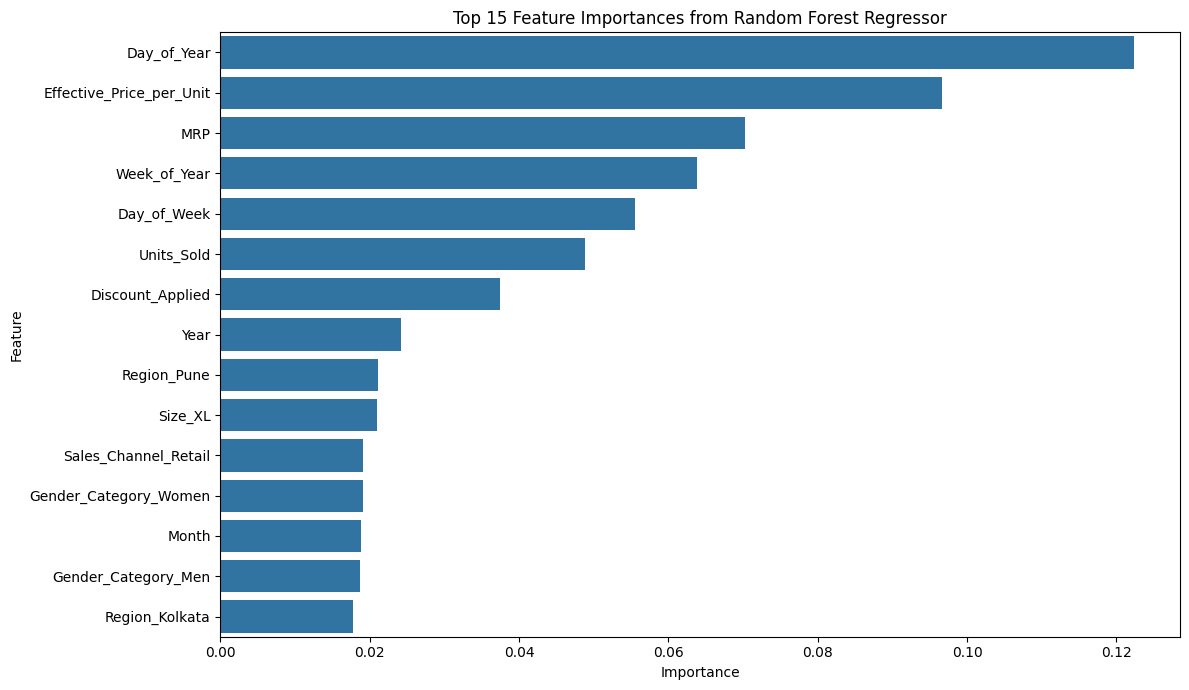

In [43]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X_scaled.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15))
plt.title('Top 15 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Next Steps: Interpreting Feature Importance and Improving the Model

The feature importance analysis can provide valuable insights into what the model focused on. Based on these results, we can consider the following improvements:

1.  **Re-evaluate Target Variable:** Given the negative R2, `Profit` might be inherently difficult to predict with the current data. We might need to reassess if we have enough information or if a different target (e.g., `Units_Sold` for a classification task, or `Revenue` if that's less noisy) would be more suitable.
2.  **Simplify the Model:** A complex model like Random Forest might be overfitting to noise if the underlying signal is weak. Trying a simpler model (e.g., Linear Regression, Decision Tree) could provide a baseline.
3.  **Hyperparameter Tuning:** While the R2 is very low, optimizing the Random Forest hyperparameters might yield a slight improvement, though it's unlikely to fix a negative R2 significantly.
4.  **Advanced Feature Engineering:** Perhaps more complex interactions between features are needed, or external data could be incorporated.
5.  **Robust Scaling/Transformation:** Review if `StandardScaler` was the best choice, or if `MinMaxScaler` or other transformations might be more appropriate, especially if the data has a highly non-normal distribution.

Let's analyze the feature importances from the previous cell and then decide on the next best course of action.

## 8. Feature Importance Analysis

Since our Random Forest Regressor performed poorly (negative R2 score), let's investigate which features the model considered most important. Understanding feature importances can help us identify potential key drivers of profit or highlight if none of our current features are providing strong predictive power.

Top 10 Feature Importances:


,Feature,Importance
6,Day_of_Year,0.122395
9,Effective_Price_per_Unit,0.096577
1,MRP,0.070317
7,Week_of_Year,0.063856
5,Day_of_Week,0.055581
0,Units_Sold,0.048845
2,Discount_Applied,0.037441
3,Year,0.024232
50,Region_Pune,0.021077
43,Size_XL,0.021008


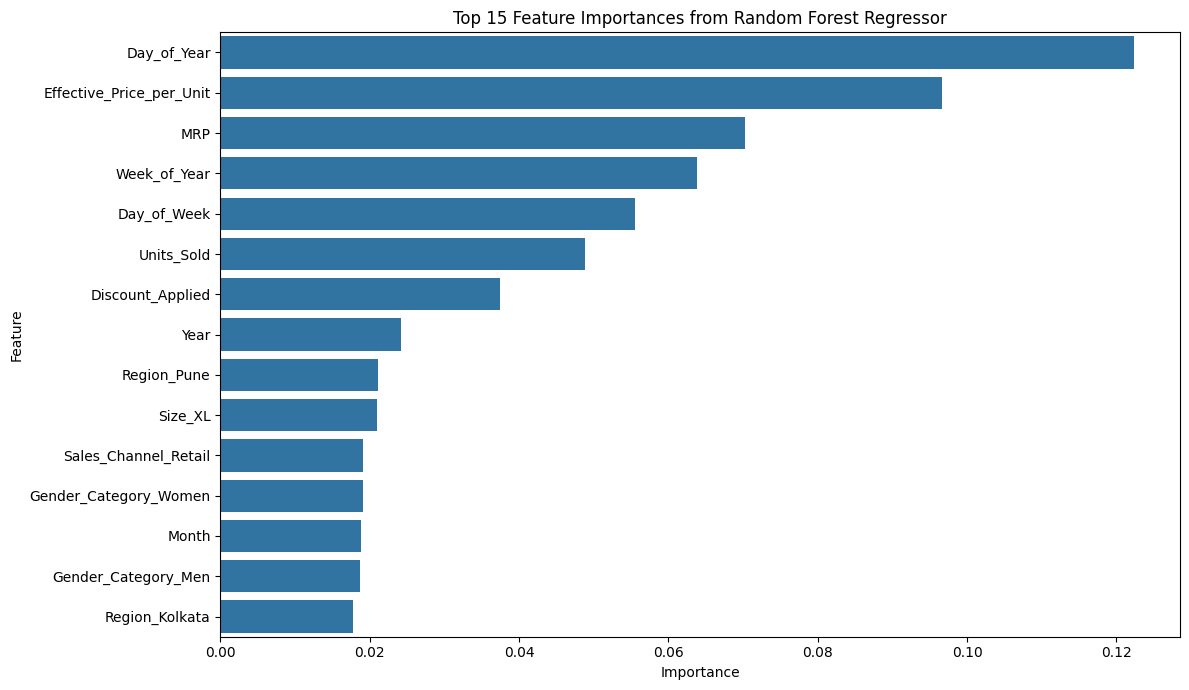

In [41]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X_scaled.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15))
plt.title('Top 15 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Next Steps: Interpreting Feature Importance and Improving the Model

The feature importance analysis can provide valuable insights into what the model focused on. Based on these results, we can consider the following improvements:

1.  **Re-evaluate Target Variable:** Given the negative R2, `Profit` might be inherently difficult to predict with the current data. We might need to reassess if we have enough information or if a different target (e.g., `Units_Sold` for a classification task, or `Revenue` if that's less noisy) would be more suitable.
2.  **Simplify the Model:** A complex model like Random Forest might be overfitting to noise if the underlying signal is weak. Trying a simpler model (e.g., Linear Regression, Decision Tree) could provide a baseline.
3.  **Hyperparameter Tuning:** While the R2 is very low, optimizing the Random Forest hyperparameters might yield a slight improvement, though it's unlikely to fix a negative R2 significantly.
4.  **Advanced Feature Engineering:** Perhaps more complex interactions between features are needed, or external data could be incorporated.
5.  **Robust Scaling/Transformation:** Review if `StandardScaler` was the best choice, or if `MinMaxScaler` or other transformations might be more appropriate, especially if the data has a highly non-normal distribution.

Let's analyze the feature importances from the previous cell and then decide on the next best course of action.

## 9. Hyperparameter Tuning for Random Forest Regressor

Given the poor performance of our initial Random Forest model, hyperparameter tuning is a critical step to try and optimize its performance. We will use `GridSearchCV` to exhaustively search for the best combination of hyperparameters for our `RandomForestRegressor`.

In [44]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

# Initialize a new Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# We will use the negative mean squared error as our scoring metric,
# as GridSearchCV tries to maximize the score, so a more negative MSE is better.
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV complete!")

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_ # Convert back to positive MSE

print(f"\nBest parameters found: {best_params}")
print(f"Best MSE found during CV (on validation sets): {best_score:.2f}")

Starting GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
GridSearchCV complete!

Best parameters found: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best MSE found during CV (on validation sets): 2308372.37


## 10. Evaluating the Tuned Random Forest Model

Now that we have found the best hyperparameters, let's train a new Random Forest model with these parameters and evaluate its performance on the test set (`X_test`).

In [45]:
# Use the best estimator found by GridSearchCV
best_rf_model = grid_search.best_estimator_

print("Making predictions with the tuned model on the test set...")
# Make predictions on the test set
y_pred_tuned = best_rf_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\n--- Tuned Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

print(f"\n--- Original Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Making predictions with the tuned model on the test set...

--- Tuned Model Performance ---
Mean Absolute Error (MAE): 1353.87
Mean Squared Error (MSE): 2415652.40
Root Mean Squared Error (RMSE): 1554.24
R-squared (R2): -0.05

--- Original Model Performance ---
Mean Absolute Error (MAE): 1397.61
Mean Squared Error (MSE): 2618954.90
Root Mean Squared Error (RMSE): 1618.32
R-squared (R2): -0.13


## 11. Visualizing Predictions vs. Actual Values for Tuned Model

Let's visualize the actual vs. predicted values and residuals for the tuned model to compare with the original model's performance.

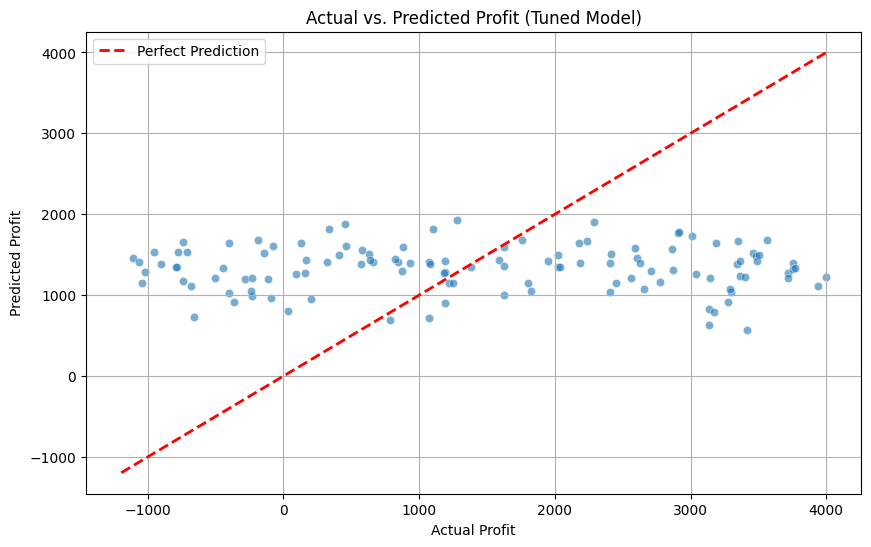

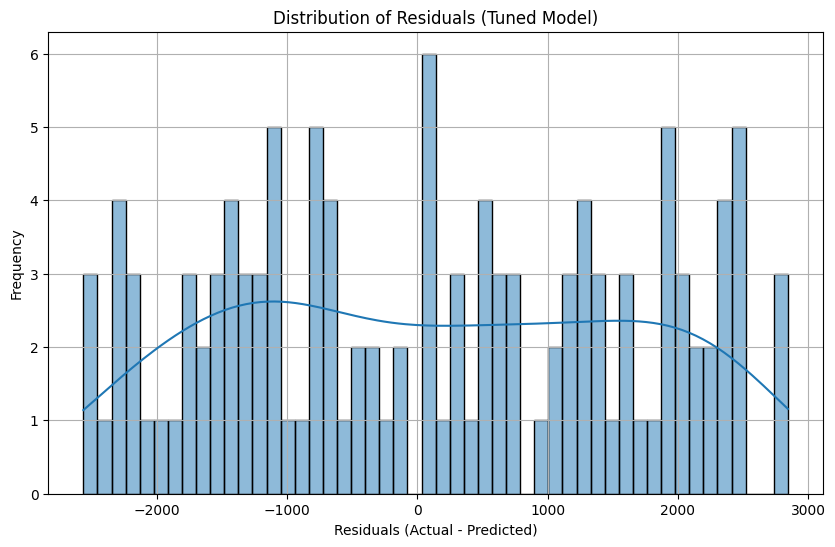

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction') # Diagonal line
plt.title('Actual vs. Predicted Profit (Tuned Model)')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.legend()
plt.grid(True)
plt.show()

residuals_tuned = y_test - y_pred_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_tuned, bins=50, kde=True)
plt.title('Distribution of Residuals (Tuned Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Top 10 Feature Importances:


,Feature,Importance
6,Day_of_Year,0.122395
9,Effective_Price_per_Unit,0.096577
1,MRP,0.070317
7,Week_of_Year,0.063856
5,Day_of_Week,0.055581
0,Units_Sold,0.048845
2,Discount_Applied,0.037441
3,Year,0.024232
50,Region_Pune,0.021077
43,Size_XL,0.021008


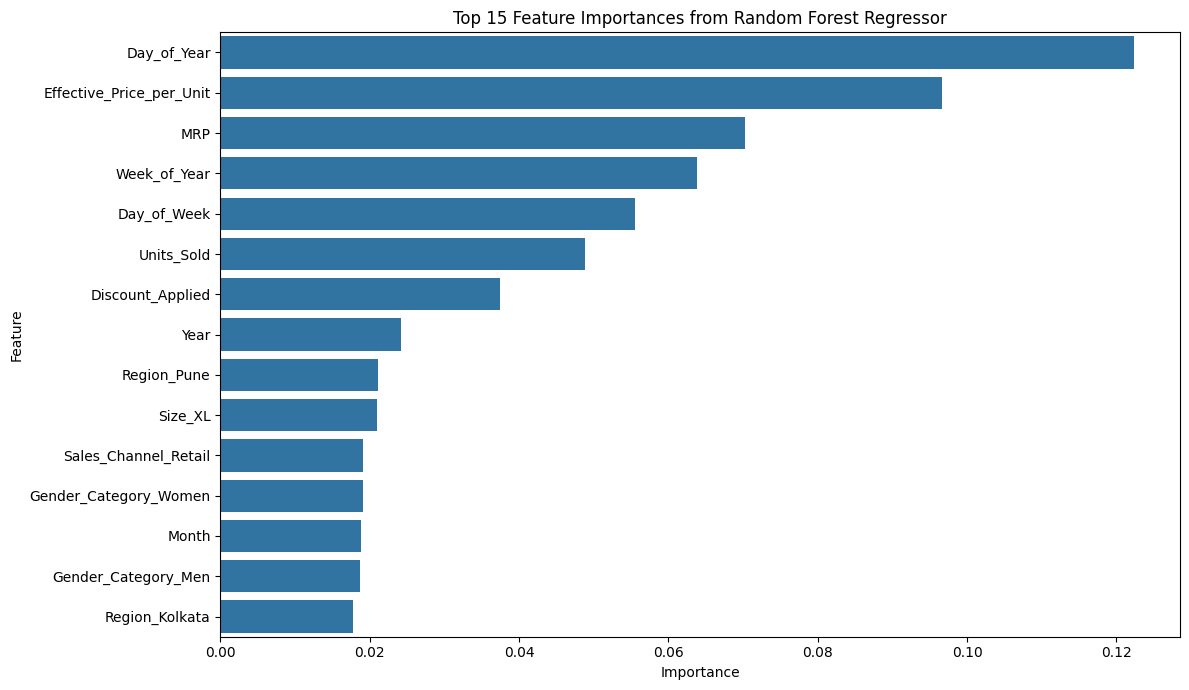

In [42]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.DataFrame({'Feature': X_scaled.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15))
plt.title('Top 15 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 12. Correlation Analysis

To understand the relationships between all numerical features in our dataset, let's compute and visualize the correlation matrix. This can help us identify highly correlated features which might indicate multicollinearity, or reveal unexpected relationships with our target variable or other important features.

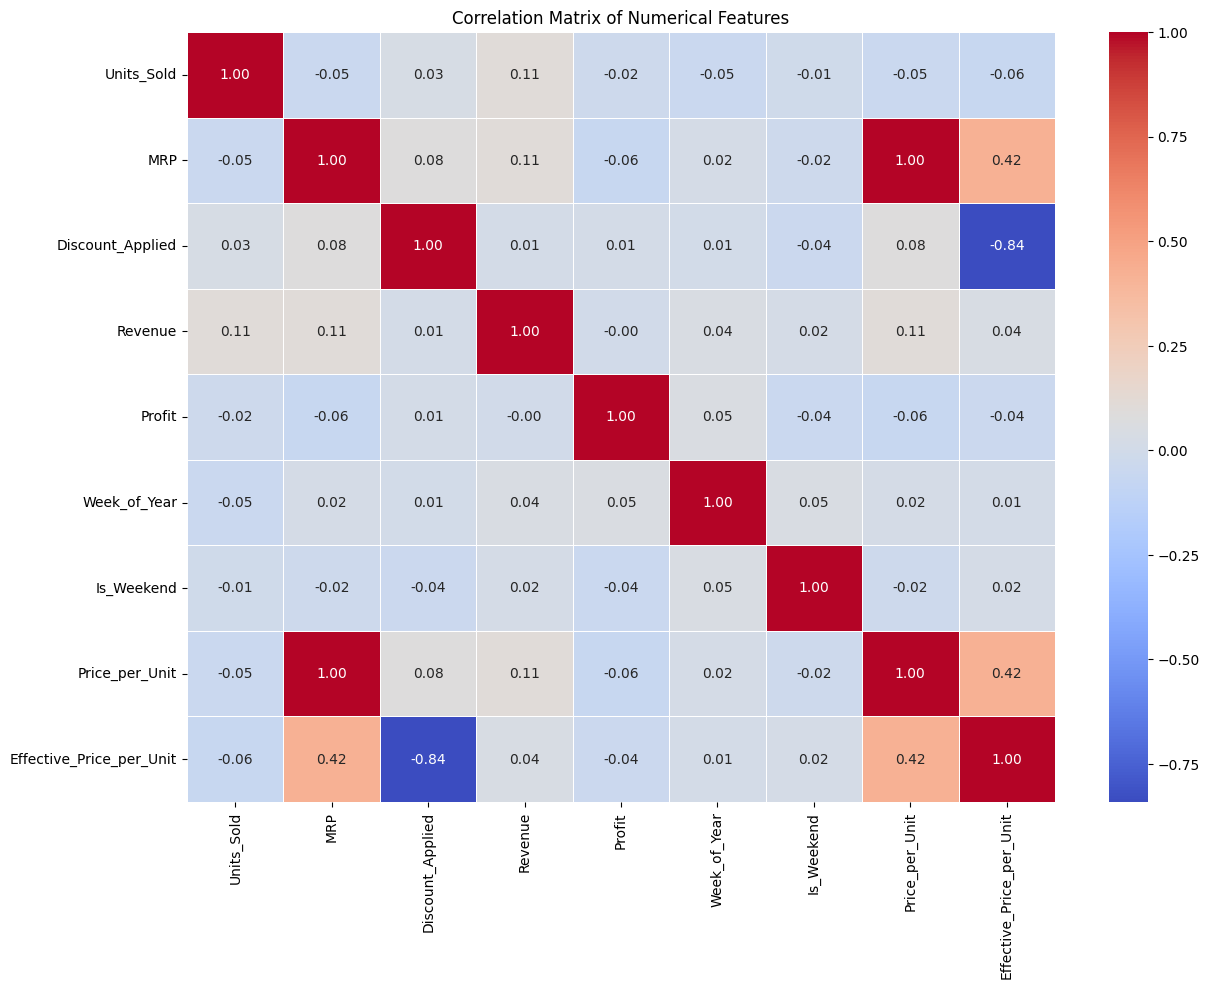

In [47]:
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64', 'datetime64[ns]'])

# Exclude 'Order_ID' from correlation as it's just an identifier
correlation_matrix = numerical_df.drop(columns=['Order_ID', 'Order_Date'], errors='ignore').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()